In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

# Ferramentas de modelagem e avaliação
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# MAPIE: conformal prediction para classificação (API nova)
from mapie.classification import SplitConformalClassifier
from mapie.metrics.classification import (
    classification_coverage_score,
    classification_mean_width_score,
)

#from mapie.classification import MapieClassifier
#from mapie.metrics import classification_coverage_score, classification_mean_width_score

In [2]:
# opcoes pandas (mostrar todas as colunas)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)
pd.set_option('display.max_colwidth', None)

# Configuracao do IPython para exibir DataFrames com scroll vertical
ip = get_ipython()

def _html_scroll(obj, max_height=300):
    """Display a scrollable HTML representation of a DataFrame or Series."""
    if isinstance(obj, pd.Series):
        obj = obj.to_frame(name = 'value')
    return "<div style='max-height:{}px; overflow:auto;'>{}</div>".format(max_height, obj.to_html())

# usar *args, **kwargs para aceitar os argumentos que o Ipython passa internamente
ip.display_formatter.formatters['text/html'].for_type(pd.DataFrame, lambda df, *args, **kwargs: _html_scroll(df))
ip.display_formatter.formatters['text/html'].for_type(pd.Series, lambda s, *args, **kwargs: _html_scroll(s))

In [3]:
dt = pd.read_pickle('/Users/mpa/Library/Mobile Documents/com~apple~CloudDocs/mba monografia/df_renamed.pkl')
dt.head()

,target,acct_bal,dur_months,cred_hist,purpose,cred_amt,savings,emp_dur,inst_rate,pers_status,guarantors,res_dur,property,age,other_creds,housing,num_creds,job,dependents,phone,foreign_worker
0,1,1,18,4,2,1049,1,2,4,2,1,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,1,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,1,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,1,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,1,4,2,38,1,2,2,2,1,1,2


In [4]:
# o dataframe df deve selecionar as variaveis abaixo e a variavel alvo cujo nome é 'target'
selecao = ['acct_bal', 'dur_months', 'cred_hist','purpose','cred_amt', 'savings', 'emp_dur', 'property', 'age']
df = dt[['target'] + selecao ]
df.head()

,target,acct_bal,dur_months,cred_hist,purpose,cred_amt,savings,emp_dur,property,age
0,1,1,18,4,2,1049,1,2,2,21
1,1,1,9,4,0,2799,1,3,1,36
2,1,2,12,2,9,841,2,4,1,23
3,1,1,12,4,0,2122,1,3,1,39
4,1,1,12,4,0,2171,1,3,2,38


DEFINIR DATA SET PARA O CASO DE TODAS AS VARIAVEIS

In [5]:
#df = dt.copy()
#df.shape

In [6]:
# gostaria de copiar o output da funcao dtypes para colar em um propt chatgpt
df.dtypes

,value
target,category
acct_bal,category
dur_months,int64
cred_hist,category
purpose,category
cred_amt,int64
savings,category
emp_dur,category
property,category
age,int64


In [7]:
# ----------------------------------------------------------------------------
# FASE 0: PREPARAÇÃO DOS DADOS - TRANSFORMAÇÃO DE CATEGÓRICAS EM NÚMEROS
# ----------------------------------------------------------------------------

df = df.copy()

# 1) Converter a coluna target de category -> int
# (se já for 0/1, isso só remove o rótulo categórico)
if pd.api.types.is_categorical_dtype(df['target']):
    df['target'] = df['target'].cat.codes.astype(int)
else:
    df['target'] = df['target'].astype(int)

# 2) Converter TODAS as demais colunas categóricas em códigos numéricos
cat_cols = df.select_dtypes(include=['category']).columns.tolist()

# Remover 'target' da lista, se ainda estiver
cat_cols = [c for c in cat_cols if c != 'target']

for col in cat_cols:
    df[col] = df[col].cat.codes.astype(int)

# Agora, todas as colunas são int64 (ou pelo menos numéricas)
print(df.dtypes)

target        int64
acct_bal      int64
dur_months    int64
cred_hist     int64
purpose       int64
cred_amt      int64
savings       int64
emp_dur       int64
property      int64
age           int64
dtype: object


/var/folders/f2/y1xp7rnd65ggry8g_j5kb19h0000gn/T/ipykernel_3225/880536220.py:9: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df['target']):


In [8]:
df.head(2)

,target,acct_bal,dur_months,cred_hist,purpose,cred_amt,savings,emp_dur,property,age
0,1,0,18,4,2,1049,0,1,1,21
1,1,0,9,4,0,2799,0,2,0,36


Pairplot

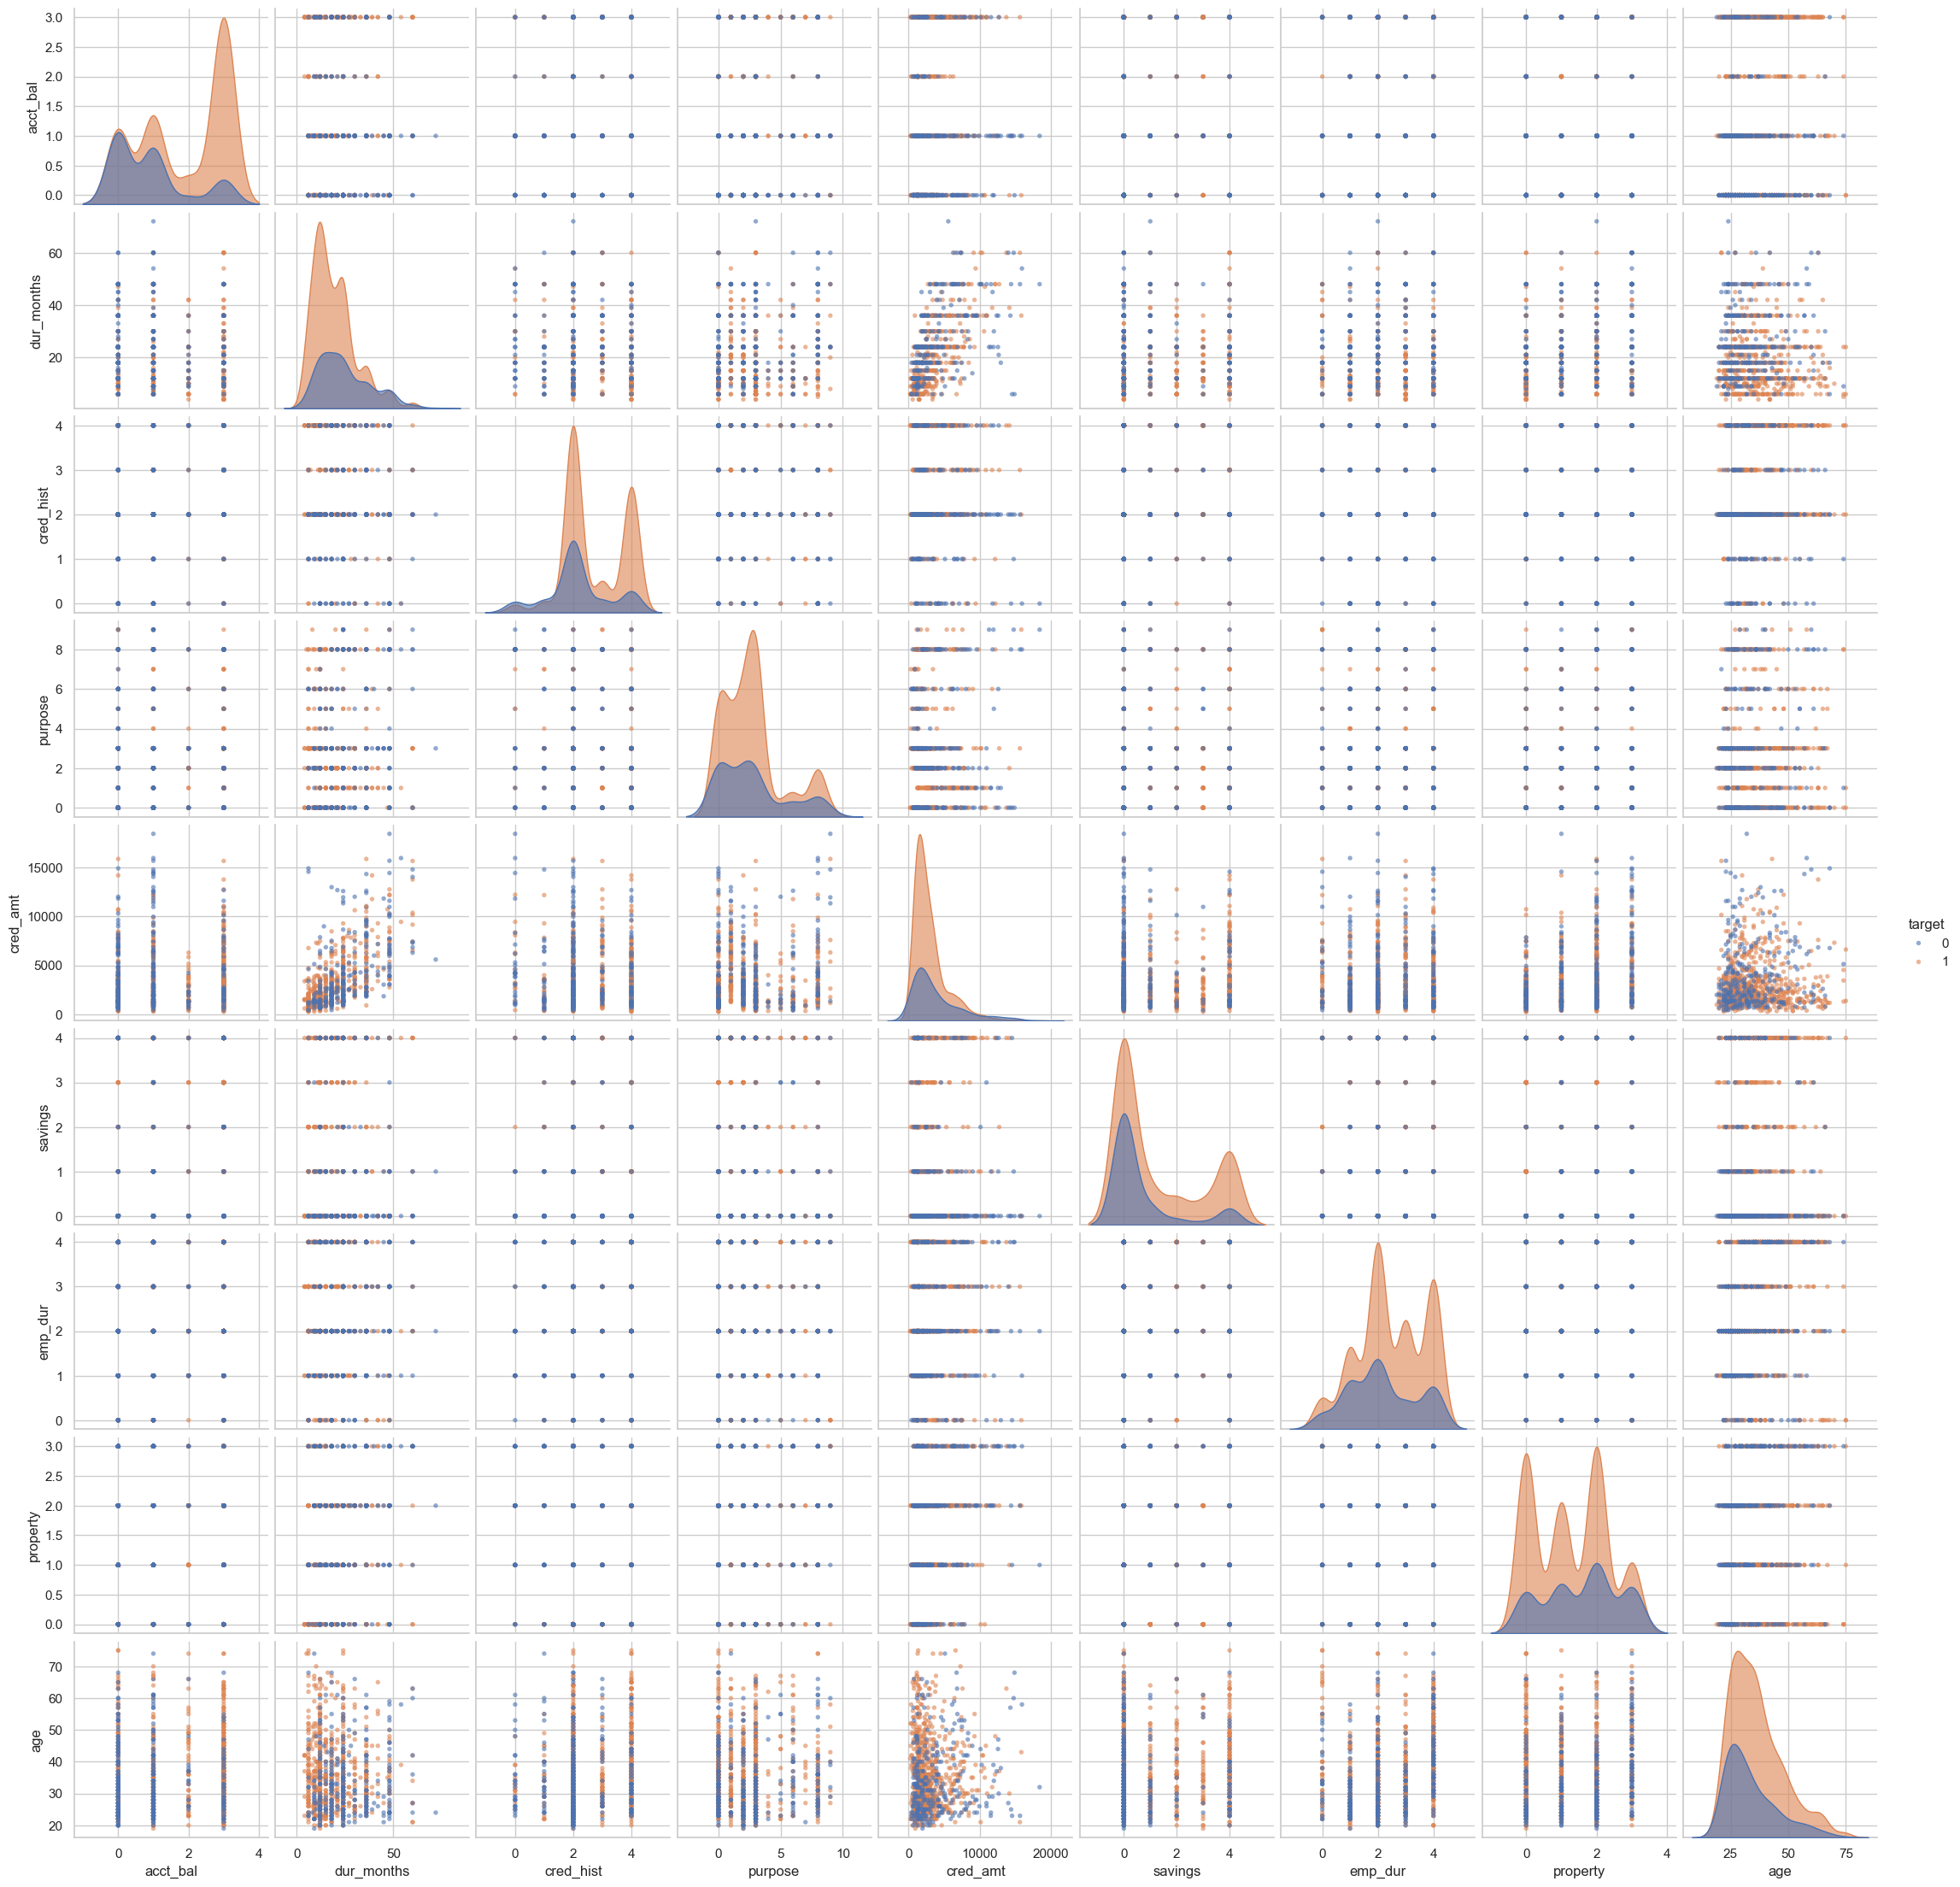

In [9]:
sns.set_theme(style="whitegrid")

pair = sns.pairplot(
    df,
    hue="target",
    plot_kws={"alpha": 0.6, "s": 15, "edgecolor": "none"},
    diag_kws={"alpha": 0.6},
)

# 3.6-inch width, 12 subplots tall gives readable axes in a two-column layout
#pair.fig.set_size_inches(3.6, 10)

#output_path = "resultado_pairplot.png"
#pair.savefig(output_path, dpi=300, bbox_inches="tight")
#plt.close(pair.fig)

print(pair)


Estatisticas descritivas das variaveis numericas

In [10]:
num_vars = ["dur_months", "cred_amt", "age"]

# Garante que target está em {0,1}
# (pule isso se você já tem nesses valores)
df["target"] = df["target"].astype(int)

# Calcula média e desvio-padrão por classe
stats = (
    df
    .groupby("target")[num_vars]
    .agg(["mean", "std"])
)

# stats tem MultiIndex nas colunas: (variável, medida)
# Vamos montar a tabela no formato:
# Variável | Média (bom) | DP (bom) | Média (mau) | DP (mau)

linhas = []
for var in num_vars:
    mean_bom = stats.loc[1, (var, "mean")]
    std_bom  = stats.loc[1, (var, "std")]
    mean_mau = stats.loc[0, (var, "mean")]
    std_mau  = stats.loc[0, (var, "std")]
    linhas.append(
        {
            "Variável": var,
            "Média (bom)": mean_bom,
            "DP (bom)": std_bom,
            "Média (mau)": mean_mau,
            "DP (mau)": std_mau,
        }
    )

tabela_desc = pd.DataFrame(linhas)

# Arredonda para 2 casas decimais
tabela_desc_rounded = tabela_desc.round(2)

print(tabela_desc_rounded)

     Variável  Média (bom)  DP (bom)  Média (mau)  DP (mau)
0  dur_months        19.21     11.08        24.86     13.28
1    cred_amt      2985.44   2401.50      3938.13   3535.82
2         age        36.22     11.35        33.96     11.23


PAIR PLOT VAARIAVEIS NUMERICAS

In [11]:
num_vars = ["dur_months", "cred_amt", "age"]

# Cópia para rotular o target de forma mais amigável
df_plot = df.copy()
df_plot["Target"] = df_plot["target"].map({1: "Bom", 0: "Mau"})

sns.set(style="whitegrid")

# Cria o pair plot
g = sns.pairplot(
    data=df_plot,
    vars=num_vars,
    hue="Target",
    diag_kind="kde",
    corner=True
)

# Ajusta o tamanho da figura pensando em duas colunas
# 1 coluna típica ≈ 3.3 inches; vamos fazer algo levemente maior para manter legibilidade
g.fig.set_size_inches(6, 6)  # largura x altura em polegadas

# Título opcional
#g.fig.suptitle("Pair plot das variáveis numéricas por classe de risco", y=1.02)

# Ajuste de layout para evitar cortes
plt.tight_layout()

# Salvar em PNG, com boa resolução, pronto para artigo
g.savefig(
    "pairplot_german_credit.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(g.fig)

In [12]:
# Define semente para reprodutibilidade
np.random.seed(42)

# Supomos que df já está no ambiente, com 9 colunas numéricas e 'target'
# Se necessário: df.head() para inspecionar
# target: 0 = mau pagador, 1 = bom pagador

# Separa X (features) e y (rótulo)
X = df.drop(columns=['target'])  # todas as colunas exceto 'target' serão preditoras
y = df['target']                 # coluna alvo binária (0/1)

In [13]:
# ------------------------------------------------------------
# FASE 1: SPLIT EM TREINO / CALIBRAÇÃO / TESTE
# ------------------------------------------------------------

# Primeiro split: Treino vs Resto
# - train_size=0.7: 70% para treino
# - stratify=y: preserva proporção de bons/m maus pagadores em ambos os conjuntos
X_train, X_rest, y_train, y_rest = train_test_split(
    X, y,
    train_size=0.7,
    random_state=42,
    stratify=y
)

# Segundo split: Resto -> Calibração vs Teste
# - Usamos y_rest no stratify, pois é o vetor correspondente a X_rest
X_calib, X_test, y_calib, y_test = train_test_split(
    X_rest, y_rest,
    train_size=0.5,
    random_state=42,
    stratify=y_rest
)

print("Tamanhos dos conjuntos:")
print(f"  Treino:      {X_train.shape[0]}")
print(f"  Calibração:  {X_calib.shape[0]}")
print(f"  Teste:       {X_test.shape[0]}")

Tamanhos dos conjuntos:
  Treino:      700
  Calibração:  150
  Teste:       150


In [14]:
# ------------------------------------------------------------
# FASE 2: FUNÇÃO AUXILIAR PARA RODAR SPLIT CONFORMAL (MAPIE)
# ------------------------------------------------------------

def rodar_conformal_com_modelo(
    estimator,
    X_train,
    y_train,
    X_calib,
    y_calib,
    X_test,
    y_test,
    alpha=0.1,
    nome_modelo=""
):
    """
    Função que:
    - treina um modelo base em X_train, y_train
    - ajusta SplitConformalClassifier (LAC) em X_calib, y_calib
    - faz predição conformal (conjuntos) em X_test
    - calcula cobertura empírica e tamanho médio do conjunto
    - imprime e retorna as métricas
    """

    # -------------------------
    # 1. Treinar modelo base
    # -------------------------
    estimator.fit(X_train, y_train)

    # -------------------------
    # 2. Criar SplitConformalClassifier
    # -------------------------
    confidence_level = 1 - alpha

    mapie_clf = SplitConformalClassifier(
        estimator=estimator,
        confidence_level=confidence_level,
        conformity_score="lac",  # equivalente ao antigo "score"
        prefit=True,
        random_state=42
    )

    # -------------------------
    # 3. Calibrar (conformalizar) o MAPIE
    # -------------------------
    mapie_clf.conformalize(X_calib, y_calib)

    # -------------------------
    # 4. Predição conformal no conjunto de teste
    # -------------------------
    y_pred, y_ps = mapie_clf.predict_set(X_test)
    # y_ps: (n_amostras, n_classes, n_confidence_levels)
    y_set = y_ps

    # Garante que y_test é array NumPy **inteiro** (não float)
    y_true = np.asarray(y_test, dtype=int)

    # -------------------------
    # 5. Métrica 1: Cobertura empírica
    # -------------------------
    cov_raw = classification_coverage_score(y_true, y_set)
    # cov_raw pode ser escalar ou array 1D; garantimos escalar:
    coverage = float(np.ravel(cov_raw)[0])

    # -------------------------
    # 6. Métrica 2: Tamanho médio do conjunto
    # -------------------------
    size_raw = classification_mean_width_score(y_set)
    set_size = float(np.ravel(size_raw)[0])

    # -------------------------
    # 7. Impressão dos resultados
    # -------------------------
    if nome_modelo:
        print(f"\n=== Resultados para {nome_modelo} ===")
    else:
        print("\n=== Resultados do modelo ===")

    print(f"Nível de confiança nominal (1 - alpha): {confidence_level:.2%}")
    print(f"Cobertura empírica no teste:           {coverage:.2%}")
    print(f"Tamanho médio do conjunto preditivo:   {set_size:.2f}")

    # Exemplo dos primeiros 5 conjuntos de previsão
    print("\nPrimeiros 5 conjuntos de previsão (classes incluídas):")
    for i in range(min(5, X_test.shape[0])):
        # vetor booleano das classes incluídas para este nível de confiança
        mask_classes = y_set[i, :, 0]
        classes_incluidas = np.where(mask_classes)[0].tolist()
        print(f"  Instância {i}: {classes_incluidas} (y verdadeiro = {int(y_true[i])})")

    return coverage, set_size



In [15]:
# ------------------------------------------------------------
# FASE 3: RODAR CONFORMAL COM NAIVE BAYES
# ------------------------------------------------------------

# Define o modelo Naive Bayes Gaussiano
nb_model = GaussianNB()

# Executa todo o pipeline conformal para Naive Bayes
cov_nb, size_nb = rodar_conformal_com_modelo(
    estimator=nb_model,
    X_train=X_train,
    y_train=y_train,
    X_calib=X_calib,
    y_calib=y_calib,
    X_test=X_test,
    y_test=y_test,
    alpha=0.1,  # 90% de confiança
    nome_modelo="Naive Bayes (GaussianNB)"
)


# ------------------------------------------------------------
# FASE 4: RODAR CONFORMAL COM RANDOM FOREST
# ------------------------------------------------------------

# Define o modelo Random Forest
rf_model = RandomForestClassifier(
    n_estimators=500,  # número de árvores
    random_state=42,   # reprodutibilidade
    n_jobs=-1          # usa todos os núcleos disponíveis
)

# Executa todo o pipeline conformal para Random Forest
cov_rf, size_rf = rodar_conformal_com_modelo(
    estimator=rf_model,
    X_train=X_train,
    y_train=y_train,
    X_calib=X_calib,
    y_calib=y_calib,
    X_test=X_test,
    y_test=y_test,
    alpha=0.1,  # mesmo nível de confiança
    nome_modelo="Random Forest"
)


=== Resultados para Naive Bayes (GaussianNB) ===
Nível de confiança nominal (1 - alpha): 90.00%
Cobertura empírica no teste:           92.00%
Tamanho médio do conjunto preditivo:   1.40

Primeiros 5 conjuntos de previsão (classes incluídas):
  Instância 0: [0, 1] (y verdadeiro = 0)
  Instância 1: [0, 1] (y verdadeiro = 0)
  Instância 2: [0, 1] (y verdadeiro = 1)
  Instância 3: [0, 1] (y verdadeiro = 1)
  Instância 4: [0, 1] (y verdadeiro = 1)

=== Resultados para Random Forest ===
Nível de confiança nominal (1 - alpha): 90.00%
Cobertura empírica no teste:           92.67%
Tamanho médio do conjunto preditivo:   1.43

Primeiros 5 conjuntos de previsão (classes incluídas):
  Instância 0: [0, 1] (y verdadeiro = 0)
  Instância 1: [0, 1] (y verdadeiro = 0)
  Instância 2: [0, 1] (y verdadeiro = 1)
  Instância 3: [0, 1] (y verdadeiro = 1)
  Instância 4: [0, 1] (y verdadeiro = 1)


In [16]:
# ------------------------------------------------------------
# FASE 5: COMPARAÇÃO RESUMIDA ENTRE OS DOIS MODELOS
# ------------------------------------------------------------

print("\n\n=== COMPARAÇÃO RESUMIDA ===")
print(f"Naive Bayes   - Cobertura: {cov_nb:.3f}, Tamanho médio do conjunto: {size_nb:.3f}")
print(f"Random Forest - Cobertura: {cov_rf:.3f}, Tamanho médio do conjunto: {size_rf:.3f}")




=== COMPARAÇÃO RESUMIDA ===
Naive Bayes   - Cobertura: 0.920, Tamanho médio do conjunto: 1.400
Random Forest - Cobertura: 0.927, Tamanho médio do conjunto: 1.427


## TESTE

BLOCO BASE (rodar uma vez antes dos 5 itens)

In [17]:

import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from mapie.classification import SplitConformalClassifier
from mapie.metrics.classification import (
    classification_coverage_score,
    classification_mean_width_score,
)
from sklearn.metrics import accuracy_score, roc_auc_score

# -----------------------------
# Definindo alpha e confiança
# -----------------------------
alpha = 0.1                       # nível de significância
confidence_level = 1 - alpha      # 0.9 = 90% de confiança

# -----------------------------
# Vetor de rótulos verdadeiros no teste
# -----------------------------
y_true = np.asarray(y_test, dtype=int)  # garante que é array de inteiros

# ============================================================
# MODELO 1: NAIVE BAYES
# ============================================================

# 1) Treina o Naive Bayes no conjunto de treino
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# 2) Cria o conformalizador SplitConformalClassifier com score LAC
mapie_nb = SplitConformalClassifier(
    estimator=nb_model,
    confidence_level=confidence_level,
    conformity_score="lac",  # equivalente ao antigo "score"
    prefit=True,
    random_state=42
)

# 3) Calibra (conformaliza) no conjunto de calibração
mapie_nb.conformalize(X_calib, y_calib)

# 4) Gera predições conformais no conjunto de teste
y_pred_nb, y_set_nb = mapie_nb.predict_set(X_test)
# y_set_nb: shape (n_amostras, n_classes, n_conf_levels)

# ============================================================
# MODELO 2: RANDOM FOREST
# ============================================================

# 1) Treina o Random Forest no conjunto de treino
rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# 2) Cria o conformalizador para RF
mapie_rf = SplitConformalClassifier(
    estimator=rf_model,
    confidence_level=confidence_level,
    conformity_score="lac",
    prefit=True,
    random_state=42
)

# 3) Calibra no conjunto de calibração
mapie_rf.conformalize(X_calib, y_calib)

# 4) Gera predições conformais no conjunto de teste
y_pred_rf, y_set_rf = mapie_rf.predict_set(X_test)


Interpretação geral:
y_set_nb e y_set_rf são as bandas de previsão em classificação (conjuntos de rótulos).
Em cada ponto, o modelo retorna um conjunto de classes (0, 1 ou {0,1}) com garantia de ≈90% de cobertura.
A partir daqui, cada item do checklist vira um bloco de código separado.

In [18]:
# ---------------------------------------------------------
# Escolha o índice do cliente no conjunto de teste
# (por exemplo, o 0-ésimo registro de X_test)
# ---------------------------------------------------------
idx = 42  # troque para 10, 42 etc. se quiser outro cliente

# ---------------------------------------------------------
# 1. Extrair a linha do X_test correspondente ao cliente
# ---------------------------------------------------------
# iloc[[idx]] mantém o formato de DataFrame (1 x n_features)
x_new = X_test.iloc[[idx]]

# Verdadeiro rótulo do cliente (0 = mau, 1 = bom)
y_true = int(y_test.iloc[idx])

print(f"Índice no X_test: {idx}")
print(f"Verdadeiro rótulo (y_true): {y_true}")

# ---------------------------------------------------------
# 2. Predição pontual e probabilidades do Random Forest
# ---------------------------------------------------------
# rótulo predito (0 ou 1)
y_pred_hard = int(rf_model.predict(x_new)[0])

# probabilidades preditas para cada classe [p(y=0), p(y=1)]
proba = rf_model.predict_proba(x_new)[0]
p0 = proba[0]   # probabilidade de mau pagador
p1 = proba[1]   # probabilidade de bom pagador

print("\n=== Modelo base (Random Forest, sem conformal) ===")
print(f"Rótulo predito: {y_pred_hard}")
print(f"Probabilidade p(y=0 | x): {p0:.3f}")
print(f"Probabilidade p(y=1 | x): {p1:.3f}")

# ---------------------------------------------------------
# 3. Conjunto preditivo conformal (MAPIE: SplitConformalClassifier)
# ---------------------------------------------------------
# predict_set retorna:
#  - y_pred_conf: predição pontual (classe mais provável)
#  - y_set_conf: máscara booleana de conjuntos (n_amostras, n_classes, n_conf_levels)
y_pred_conf, y_set_conf = mapie_rf.predict_set(x_new)

# como x_new tem apenas 1 linha, pegamos o primeiro elemento
y_pred_conf = int(y_pred_conf[0])

# máscara booleana do conjunto para este cliente e este nível de confiança
# shape: (n_classes,) -> por ex., [True, False], [False, True] ou [True, True]
mask_conjunto = y_set_conf[0, :, 0]

# classes incluídas no conjunto preditivo Γ(x)
classes_incluidas = np.where(mask_conjunto)[0].tolist()

print("\n=== Conformal Prediction (Random Forest + MAPIE) ===")
print(f"Rótulo conformal (y_pred_conf): {y_pred_conf}")
print(f"Conjunto preditivo Γ(x): {classes_incluidas}")
print("Interpretação de Γ(x):")
print("  {0}   -> modelo confiante em 'mau pagador'")
print("  {1}   -> modelo confiante em 'bom pagador'")
print("  {0,1} -> caso ambíguo / zona cinza")

# ---------------------------------------------------------
# 4. Resumo final do cliente
# ---------------------------------------------------------
print("\n=== RESUMO DO CLIENTE ===")
print(f"Índice no teste: {idx}")
print(f"Verdadeiro rótulo (y_true): {y_true}")
print(f"Rótulo ponto (RF): {y_pred_hard}")
print(f"Probabilidades RF: p0={p0:.3f}, p1={p1:.3f}")
print(f"Conjunto conformal Γ(x): {classes_incluidas}")


Índice no X_test: 42
Verdadeiro rótulo (y_true): 1

=== Modelo base (Random Forest, sem conformal) ===
Rótulo predito: 0
Probabilidade p(y=0 | x): 0.582
Probabilidade p(y=1 | x): 0.418

=== Conformal Prediction (Random Forest + MAPIE) ===
Rótulo conformal (y_pred_conf): 0
Conjunto preditivo Γ(x): [0, 1]
Interpretação de Γ(x):
  {0}   -> modelo confiante em 'mau pagador'
  {1}   -> modelo confiante em 'bom pagador'
  {0,1} -> caso ambíguo / zona cinza

=== RESUMO DO CLIENTE ===
Índice no teste: 42
Verdadeiro rótulo (y_true): 1
Rótulo ponto (RF): 0
Probabilidades RF: p0=0.582, p1=0.418
Conjunto conformal Γ(x): [0, 1]


## OUTROS TESTES E INSIGHTS PARA AREA DE NEGOCIO

assumir que:

- já fez a FASE 0 e FASE 1 (conversão de category → int, X_train, X_calib, X_test, etc.).
- Vamos usar alpha = 0.1 (nível de confiança 90%) como base.
- Vou montar um bloco base para recriar mapie_nb, mapie_rf, y_true, y_set_nb, y_set_rf — isso resolve o erro NameError: name 'mapie_nb' is not defined.

In [19]:
from sklearn.metrics import accuracy_score, roc_auc_score

# -----------------------------
# Definindo alpha e confiança
# -----------------------------
alpha = 0.1                       # nível de significância
confidence_level = 1 - alpha      # 0.9 = 90% de confiança

# -----------------------------
# Vetor de rótulos verdadeiros no teste
# -----------------------------
y_true = np.asarray(y_test, dtype=int)  # garante que é array de inteiros

# ============================================================
# MODELO 1: NAIVE BAYES
# ============================================================

# 1) Treina o Naive Bayes no conjunto de treino
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# 2) Cria o conformalizador SplitConformalClassifier com score LAC
mapie_nb = SplitConformalClassifier(
    estimator=nb_model,
    confidence_level=confidence_level,
    conformity_score="lac",  # equivalente ao antigo "score"
    prefit=True,
    random_state=42
)

# 3) Calibra (conformaliza) no conjunto de calibração
mapie_nb.conformalize(X_calib, y_calib)

# 4) Gera predições conformais no conjunto de teste
y_pred_nb, y_set_nb = mapie_nb.predict_set(X_test)
# y_set_nb: shape (n_amostras, n_classes, n_conf_levels)

# ============================================================
# MODELO 2: RANDOM FOREST
# ============================================================

# 1) Treina o Random Forest no conjunto de treino
rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# 2) Cria o conformalizador para RF
mapie_rf = SplitConformalClassifier(
    estimator=rf_model,
    confidence_level=confidence_level,
    conformity_score="lac",
    prefit=True,
    random_state=42
)

# 3) Calibra no conjunto de calibração
mapie_rf.conformalize(X_calib, y_calib)

# 4) Gera predições conformais no conjunto de teste
y_pred_rf, y_set_rf = mapie_rf.predict_set(X_test)

Interpretação geral:

- y_set_nb e y_set_rf são as bandas de previsão em classificação (conjuntos de rótulos).
- Em cada ponto, o modelo retorna um conjunto de classes (0, 1 ou {0,1}) com garantia de ≈90% de cobertura.


### 1. Proporção de conjuntos vazios (|Γ| = 0)

In [20]:
# ============================================================
# ITEM 1: PROPORÇÃO DE CONJUNTOS VAZIOS (|Γ| = 0) - RANDOM FOREST
# ============================================================

# Seleciona o "slice" do nível de confiança (só temos 1 nível -> índice 0)
y_mask_rf = y_set_rf[:, :, 0]    # shape: (n_amostras, n_classes)

# Calcula o tamanho do conjunto para cada amostra
# (soma dos True em cada linha = número de classes incluídas)
set_sizes_rf = y_mask_rf.sum(axis=1)   # vetor de tamanho n_amostras

# Máscara de conjuntos vazios: tamanho 0
empty_mask_rf = (set_sizes_rf == 0)

# Proporção de conjuntos vazios
prop_empty_rf = empty_mask_rf.mean()

print("=== ITEM 1: Conjuntos vazios (Random Forest) ===")
print(f"Número de amostras no teste: {len(set_sizes_rf)}")
print(f"Número de conjuntos vazios: {empty_mask_rf.sum()}")
print(f"Proporção de conjuntos vazios: {prop_empty_rf:.4f}")


=== ITEM 1: Conjuntos vazios (Random Forest) ===
Número de amostras no teste: 150
Número de conjuntos vazios: 0
Proporção de conjuntos vazios: 0.0000


Como interpretar:

- set_sizes_rf[i] = tamanho de Γ(xᵢ):
    - 0 → conjunto vazio (algo estranho)
    - 1 → {0} ou {1}
    - 2 → {0,1}

- prop_empty_rf deve ser 0 ou muito próximo de 0. Se for grande:
- o conformalizador está falhando em encontrar um conjunto com cobertura desejada;
- ou há algum bug na calibração / dados.

Você pode repetir para o Naive Bayes trocando y_set_rf por y_set_nb.

### 2. Cobertura separada por classe (bom vs mau pagador)

In [21]:
# ============================================================
# ITEM 2: COBERTURA POR CLASSE (y = 0 e y = 1) - RANDOM FOREST
# ============================================================

# Slice da máscara de conjuntos para RF (nível de confiança único)
y_mask_rf = y_set_rf[:, :, 0]  # (n_amostras, n_classes)

# Para cada amostra i, verifica se a classe verdadeira y_true[i]
# está incluída no conjunto Γ(x_i)
indices = np.arange(len(y_true))                     # [0, 1, 2, ..., n-1]
in_set_rf = y_mask_rf[indices, y_true]               # booleano: True se classe correta está no conjunto

# Cobertura global (deve bater com ~92-93%)
coverage_global_rf = in_set_rf.mean()

# Cobertura por classe:
mask_class0 = (y_true == 0)
mask_class1 = (y_true == 1)

coverage_0_rf = in_set_rf[mask_class0].mean()
coverage_1_rf = in_set_rf[mask_class1].mean()

print("=== ITEM 2: Cobertura por classe (Random Forest) ===")
print(f"Cobertura global:      {coverage_global_rf:.3f}")
print(f"Cobertura para y = 0:  {coverage_0_rf:.3f}")
print(f"Cobertura para y = 1:  {coverage_1_rf:.3f}")
print(f"N (y=0): {mask_class0.sum()},  N (y=1): {mask_class1.sum()}")


=== ITEM 2: Cobertura por classe (Random Forest) ===
Cobertura global:      0.927
Cobertura para y = 0:  0.778
Cobertura para y = 1:  0.990
N (y=0): 45,  N (y=1): 105


Como interpretar:

- coverage_global_rf → deve estar ≈ 0.9–0.93 (nível alvo).
- coverage_0_rf vs coverage_1_rf:
    - Se forem muito diferentes (ex.: 0.95 vs 0.85), indica que o modelo:
        - cobre muito bem bons pagadores, mas falha com maus (ou o contrário);
        - isso importa muito para risco (viés de cobertura entre classes).

- Em comitê de risco, isso vira uma análise tipo:
    - “O método é válido em média, mas para a classe ‘mau pagador’ a cobertura é X%, precisamos avaliar se esse nível é aceitável dada a política de risco”.

Pode repetir o mesmo raciocínio para y_set_nb (Naive Bayes).

### 3. Distribuição de tamanhos de conjunto ({0}, {1}, {0,1})

In [22]:
# ============================================================
# ITEM 3: DISTRIBUIÇÃO DOS TAMANHOS DE CONJUNTO - RANDOM FOREST
# ============================================================

y_mask_rf = y_set_rf[:, :, 0]           # (n_amostras, n_classes)
set_sizes_rf = y_mask_rf.sum(axis=1)    # tamanho de Γ(x_i) para cada i

# Proporções de cada tamanho de conjunto
prop_size1_rf = (set_sizes_rf == 1).mean()   # conjuntos unitários {0} ou {1}
prop_size2_rf = (set_sizes_rf == 2).mean()   # conjuntos ambiguos {0,1}
prop_size0_rf = (set_sizes_rf == 0).mean()   # (idealmente 0)

print("=== ITEM 3: Distribuição de tamanhos de conjunto (Random Forest) ===")
print(f"Proporção |Γ| = 1 (decisão clara):    {prop_size1_rf:.3f}")
print(f"Proporção |Γ| = 2 (zona cinza):      {prop_size2_rf:.3f}")
print(f"Proporção |Γ| = 0 (conj. vazio):     {prop_size0_rf:.3f}")

# Opcional: dentro dos conjuntos unitários, separar {0} e {1}
mask_singleton = (set_sizes_rf == 1)
# classes incluídas quando |Γ|=1
singletons_mask = y_mask_rf[mask_singleton, :]   # apenas linhas com tamanho 1

# proporção de singletons que são {1}
if singletons_mask.shape[0] > 0:
    prop_singleton_class1 = singletons_mask[:, 1].mean()
    prop_singleton_class0 = singletons_mask[:, 0].mean()
else:
    prop_singleton_class1 = np.nan
    prop_singleton_class0 = np.nan

print("\nDentro dos conjuntos unitários (|Γ|=1):")
print(f"  Proporção de {1} (bom pagador): {prop_singleton_class1:.3f}")
print(f"  Proporção de {0} (mau pagador): {prop_singleton_class0:.3f}")


=== ITEM 3: Distribuição de tamanhos de conjunto (Random Forest) ===
Proporção |Γ| = 1 (decisão clara):    0.573
Proporção |Γ| = 2 (zona cinza):      0.427
Proporção |Γ| = 0 (conj. vazio):     0.000

Dentro dos conjuntos unitários (|Γ|=1):
  Proporção de 1 (bom pagador): 0.919
  Proporção de 0 (mau pagador): 0.081


Como interpretar:

- prop_size1_rf → % de casos com decisão clara ({0} ou {1}):
    - candidatos a decisão automática.
- prop_size2_rf → % de casos com zona cinza ({0,1}):
    - candidatos a análise manual, limite reduzido, pedido de mais documentos etc.
- prop_size0_rf → deve ser ~0.
- prop_singleton_class1 vs prop_singleton_class0:
    - mostra se, entre os casos “claros”, o modelo está mais confiante em bons ou maus pagadores.

Essa tabela é ótima para o slide “Quantos casos vão para análise manual?”.

### 4. Sensibilidade a α (alpha = 0.05, 0.1, 0.2)
Aqui vamos recalibrar o Random Forest com diferentes níveis de confiança e ver o trade-off:

In [23]:
# ============================================================
# ITEM 4: SENSIBILIDADE A α (Random Forest)
# ============================================================

alphas = [0.05, 0.10, 0.20]  # 95%, 90%, 80% de confiança
results_sensitivity = []

for alpha_val in alphas:
    conf_lvl = 1 - alpha_val

    # 1) Recria um conformalizador para este nível de confiança
    mapie_rf_alpha = SplitConformalClassifier(
        estimator=rf_model,             # já treinado
        confidence_level=conf_lvl,
        conformity_score="lac",
        prefit=True,
        random_state=42
    )

    # 2) Recalibra no mesmo conjunto de calibração
    mapie_rf_alpha.conformalize(X_calib, y_calib)

    # 3) Gera conjuntos preditivos
    y_pred_alpha, y_set_alpha = mapie_rf_alpha.predict_set(X_test)

    # 4) Calcula cobertura e largura média
    cov_alpha = classification_coverage_score(y_true, y_set_alpha)
    width_alpha = classification_mean_width_score(y_set_alpha)

    cov_alpha = float(np.ravel(cov_alpha)[0])
    width_alpha = float(np.ravel(width_alpha)[0])

    results_sensitivity.append((alpha_val, conf_lvl, cov_alpha, width_alpha))

# Imprime resultados em forma de "tabela"
print("=== ITEM 4: Sensibilidade a alpha (Random Forest) ===")
print("alpha | conf_level | cobertura_empirica | tamanho_medio_conjunto")
for alpha_val, conf_lvl, cov_alpha, width_alpha in results_sensitivity:
    print(f"{alpha_val:5.2f} |   {conf_lvl:5.2f}    |      {cov_alpha:6.3f}      |        {width_alpha:6.3f}")


=== ITEM 4: Sensibilidade a alpha (Random Forest) ===
alpha | conf_level | cobertura_empirica | tamanho_medio_conjunto
 0.05 |    0.95    |       0.980      |         1.633
 0.10 |    0.90    |       0.927      |         1.427
 0.20 |    0.80    |       0.833      |         1.093


Como interpretar:

- Você deve ver algo como:
    - α = 0.05 → conf_level = 0.95 → cobertura ≈ 0.95+ e tamanho_médio ≈ mais próximo de 2
    - α = 0.10 → conf_level = 0.90 → cobertura ≈ 0.90+ e tamanho_médio ≈ ~1.4
    - α = 0.20 → conf_level = 0.80 → cobertura ≈ 0.80+ e tamanho_médio ≈ mais perto de 1.2

A frase para o comitê de risco:
- “Se exigirmos mais confiança (95%), o modelo precisa usar conjuntos maiores (mais casos {0,1}).
- Se aceitarmos menos confiança (80%), conseguimos decisões mais objetivas (mais conjuntos unitários), ao preço de maior risco de erro.”

### 5. Comparar com o modelo “puro” (sem conformal)

Aqui vamos comparar:

- Acurácia e AUC do classificador puro
- Cobertura e tamanho do conjunto com conformal

#### 5.1. Métricas do modelo base (sem conformal)

In [24]:
# ============================================================
# ITEM 5: MODELO PURO vs CONFORMAL - RANDOM FOREST
# ============================================================

# Predição PONTUAL usual (sem conformal) no conjunto de teste
y_pred_rf_hard = rf_model.predict(X_test)                 # rótulo 0/1
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]         # probabilidade de y=1 (bom pagador)

# Acurácia
acc_rf = accuracy_score(y_true, y_pred_rf_hard)

# AUC-ROC
auc_rf = roc_auc_score(y_true, y_proba_rf)

print("=== ITEM 5 (a): Modelo puro - Random Forest ===")
print(f"Acurácia (sem conformal): {acc_rf:.3f}")
print(f"AUC-ROC (sem conformal):  {auc_rf:.3f}")

=== ITEM 5 (a): Modelo puro - Random Forest ===
Acurácia (sem conformal): 0.800
AUC-ROC (sem conformal):  0.813


#### 5.2. Métricas do modelo conformal (já calculadas com MAPIE)
Reaproveitando o mapie_rf do BLOCO BASE (α = 0.1, conf_level = 0.9):

In [25]:
# Cobertura e largura das bandas conformais (já temos y_set_rf)
cov_rf_conf = classification_coverage_score(y_true, y_set_rf)
width_rf_conf = classification_mean_width_score(y_set_rf)

cov_rf_conf = float(np.ravel(cov_rf_conf)[0])
width_rf_conf = float(np.ravel(width_rf_conf)[0])

print("\n=== ITEM 5 (b): Modelo conformal - Random Forest ===")
print(f"Cobertura empírica (conformal, 90% alvo): {cov_rf_conf:.3f}")
print(f"Tamanho médio do conjunto (conformal):    {width_rf_conf:.3f}")


=== ITEM 5 (b): Modelo conformal - Random Forest ===
Cobertura empírica (conformal, 90% alvo): 0.927
Tamanho médio do conjunto (conformal):    1.427


Como interpretar para stakeholder:

- Parte (a):
    - “O nosso classificador Random Forest, sozinho, atinge acurácia de X% e AUC de Y%. Ou seja, ele separa razoavelmente bem bons e maus pagadores.”
- Parte (b):
    - “Quando adicionamos a camada de Conformal Prediction, mantendo o mesmo classificador, passamos a ter conjuntos de decisão que, em ≈ Z% dos casos, contêm a classe verdadeira e, em média, têm tamanho W (entre 1 e 2).”
- “Isso nos permite:
    - Manter boa performance (AUC, acurácia);
    - E controlar explicitamente o risco por meio da cobertura garantida + identificação dos casos ambíguos.”

- Você pode repetir o mesmo bloco para o Naive Bayes trocando rf_model → nb_model, y_set_rf → y_set_nb, etc., e comparar:
    - NB: cobertura X, tamanho médio Y, acurácia/AUC menores
    - RF: melhor AUC, cobertura similar, tamanho de conjunto comparável.

In [26]:
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Pré-requisito: já ter rodado, para CADA modelo:
#   y_pred_nb, y_set_nb = mapie_nb.predict_set(X_test)
#   y_pred_rf, y_set_rf = mapie_rf.predict_set(X_test)
# e já ter y_test definido (Pandas Series)
# ------------------------------------------------------------

# Converte y_test para array NumPy de inteiros
y_true = np.asarray(y_test, dtype=int)

# Guarda o índice original do conjunto de teste
idx_test = y_test.index


def resumo_zonas(y_true, y_set, idx, nome_modelo=""):
    """
    Constrói:
      - df_res: tabela linha-a-linha com zona (clara/cinza/vazio) para cada observação
      - tab_resumo: tabela agregada Y x zona (contagens)
    a partir da saída y_set do MAPIE (predict_set).
    """

    # y_set: shape (n_amostras, n_classes, n_conf_levels)
    # Aqui, temos 2 classes (0 e 1) e só 1 nível de confiança
    y_mask = y_set[:, :, 0]             # (n_amostras, 2), booleano: se a classe está em C_n(x)

    # Tamanho do conjunto preditivo |C_n(x_i)| = nº de classes incluídas
    set_sizes = y_mask.sum(axis=1)      # vetor de 1, 2 (e eventualmente 0)

    # Rótulo da "zona":
    #  - clara: |C| = 1  -> decisão automática
    #  - cinza: |C| = 2  -> zona cinza (pede análise extra)
    #  - vazio: |C| = 0  -> patológico (devia ser ~0% dos casos)
    zona = np.where(
        set_sizes == 1, "clara",
        np.where(set_sizes == 2, "cinza", "vazio")
    )

    # Opcional: qual classe está no conjunto quando |C|=1 (só para consulta)
    # Se singleton e classe 1 está em C -> decisão "1"
    # Se singleton e classe 0 está em C -> decisão "0"
    classe_decisao = np.where(
        (set_sizes == 1) & y_mask[:, 1], 1,
        np.where((set_sizes == 1) & y_mask[:, 0], 0, np.nan)
    )

    # DataFrame detalhado: uma linha por cliente de teste
    df_res = pd.DataFrame({
        "modelo": nome_modelo,
        "y_true": y_true,
        "zona": zona,
        "set_size": set_sizes,
        "in_C_0": y_mask[:, 0],      # True se classe 0 está no conjunto
        "in_C_1": y_mask[:, 1],      # True se classe 1 está no conjunto
        "classe_decisao_singleton": classe_decisao  # só faz sentido se zona = "clara"
    }, index=idx)

    # Tabela resumo: contagem por (y_true, zona)
    tab_resumo = (
        df_res
        .groupby(["y_true", "zona"])
        .size()
        .unstack(fill_value=0)       # colunas = zonas, linhas = y_true
        .rename_axis(index="y_true", columns="zona")
    )

    return df_res, tab_resumo


# ------------------------------------------------------------
# Naive Bayes
# ------------------------------------------------------------
df_nb, tab_nb = resumo_zonas(
    y_true=y_true,
    y_set=y_set_nb,
    idx=idx_test,
    nome_modelo="Naive Bayes"
)

print("=== Resumo por zona - Naive Bayes ===")
print(tab_nb)
print("\nExemplos de linhas detalhadas (Naive Bayes):")
print(df_nb.head())


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------
df_rf, tab_rf = resumo_zonas(
    y_true=y_true,
    y_set=y_set_rf,
    idx=idx_test,
    nome_modelo="Random Forest"
)

print("\n\n=== Resumo por zona - Random Forest ===")
print(tab_rf)
print("\nExemplos de linhas detalhadas (Random Forest):")
print(df_rf.head())


=== Resumo por zona - Naive Bayes ===
zona    cinza  clara
y_true              
0          25     20
1          35     70

Exemplos de linhas detalhadas (Naive Bayes):
          modelo  y_true   zona  set_size  in_C_0  in_C_1  \
788  Naive Bayes       0  cinza         2    True    True   
912  Naive Bayes       0  cinza         2    True    True   
383  Naive Bayes       1  cinza         2    True    True   
613  Naive Bayes       1  cinza         2    True    True   
736  Naive Bayes       1  cinza         2    True    True   

     classe_decisao_singleton  
788                       NaN  
912                       NaN  
383                       NaN  
613                       NaN  
736                       NaN  


=== Resumo por zona - Random Forest ===
zona    cinza  clara
y_true              
0          29     16
1          35     70

Exemplos de linhas detalhadas (Random Forest):
            modelo  y_true   zona  set_size  in_C_0  in_C_1  \
788  Random Forest       0  cinza   

In [32]:
#pip install --upgrade kaleido
#!pip install -U kaleido

In [38]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import kaleido

# Função auxiliar (igual à sua)
def prepara_arrays(tab):
    labels = tab.index.astype(str).tolist()
    valores_cinza = tab["cinza"].values
    valores_clara = tab["clara"].values
    return labels, valores_cinza, valores_clara

labels_nb, cinza_nb, clara_nb = prepara_arrays(tab_nb)
labels_rf, cinza_rf, clara_rf = prepara_arrays(tab_rf)

# Figura com 2 subplots lado a lado
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Naive Bayes", "Random Forest"),
    shared_yaxes=True
)

# Paleta mais agradável
cor_cinza = "#4C78A8"   # azul
cor_clara = "#F58518"   # laranja

# --- Naive Bayes ---
fig.add_trace(
    go.Bar(
        x=labels_nb,
        y=cinza_nb,
        name="gray zone",
        marker_color=cor_cinza,
        text=cinza_nb,
        textposition="inside"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=labels_nb,
        y=clara_nb,
        name="clear zone",
        marker_color=cor_clara,
        text=clara_nb,
        textposition="inside"
    ),
    row=1, col=1
)

# --- Random Forest ---
fig.add_trace(
    go.Bar(
        x=labels_rf,
        y=cinza_rf,
        name="gray zone",
        marker_color=cor_cinza,
        showlegend=False,
        text=cinza_rf,
        textposition="inside"
    ),
    row=1, col=2
)

fig.add_trace(
    go.Bar(
        x=labels_rf,
        y=clara_rf,
        name="clear zone",
        marker_color=cor_clara,
        showlegend=False,
        text=clara_rf,
        textposition="inside"
    ),
    row=1, col=2
)

# Ajuste geral de layout
fig.update_layout(
    barmode="group",         # barras agrupadas
    bargap=0.25,             # espaço entre grupos
    bargroupgap=0.15,        # espaço entre barras do mesmo grupo
    template="plotly_white", # fundo clean
    # Ajusta o tamanho da figura pensando em duas colunas
    # Largura ~800 px e altura ~350 px encaixam bem com \includegraphics[width=0.48\textwidth]
    width=800,
    height=350,
    xaxis_title="True target (y)",
    xaxis2_title="True target (y)",
    yaxis_title="# of customers"
)

fig.update_layout(
    barmode="group",
    bargap=0.25,
    bargroupgap=0.15,
    width=800,    # largura em pixels
    height=350,   # altura em pixels
    xaxis_title="True target (y)",
    xaxis2_title="True target (y)",
    yaxis_title="# of customers",
    template="plotly_white"
)

# --- salvar em PNG com boa qualidade para artigo duas colunas ---
# precisa do pacote "kaleido" instalado
fig.write_image(
    "/Users/mpa/Library/Mobile Documents/com~apple~CloudDocs/mba monografia/zones_true_target_models_2.png",
    format="png",
    width=800,
    height=350,
    scale=3  # aumenta a resolução (equivalente a mais dpi)
)

# opcional: ainda mostrar na tela
fig.show()


In [39]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def prepara_arrays(tab):
    labels = tab.index.astype(str).tolist()
    valores_cinza = tab["cinza"].values
    valores_clara = tab["clara"].values
    return labels, valores_cinza, valores_clara

labels_nb, cinza_nb, clara_nb = prepara_arrays(tab_nb)
labels_rf, cinza_rf, clara_rf = prepara_arrays(tab_rf)

# Figura com 2 subplots lado a lado
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Naive Bayes", "Random Forest"),
    shared_yaxes=True
)

# Paleta mais agradável
cor_cinza = "#4C78A8"   # azul
cor_clara = "#F58518"   # laranja

# --- Naive Bayes ---
fig.add_trace(
    go.Bar(
        x=labels_nb,
        y=cinza_nb,
        name="gray zone",
        marker_color=cor_cinza,
        text=cinza_nb,
        textposition="inside"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=labels_nb,
        y=clara_nb,
        name="clear zone",
        marker_color=cor_clara,
        text=clara_nb,
        textposition="inside"
    ),
    row=1, col=1
)

# --- Random Forest ---
fig.add_trace(
    go.Bar(
        x=labels_rf,
        y=cinza_rf,
        name="gray zone",
        marker_color=cor_cinza,
        showlegend=False,
        text=cinza_rf,
        textposition="inside"
    ),
    row=1, col=2
)

fig.add_trace(
    go.Bar(
        x=labels_rf,
        y=clara_rf,
        name="clear zone",
        marker_color=cor_clara,
        showlegend=False,
        text=clara_rf,
        textposition="inside"
    ),
    row=1, col=2
)

fig.update_layout(
    barmode="group",         # barras agrupadas
    bargap=0.25,             # espaço entre grupos
    bargroupgap=0.15,        # espaço entre barras do mesmo grupo (barras mais finas)
    width=800,               # figura menor
    height=350,
    #title="Zonas por target verdadeiro",
    xaxis_title="True target (y)",
    xaxis2_title="True target (y)",
    yaxis_title="# of customers",
    template="plotly_white"  # fundo clean
)

fig.show()



In [ ]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ---------------------------------------------------
# 1. Função auxiliar: calcula percentuais globais
# ---------------------------------------------------
def calcula_percentuais(tab):
    """
    tab: DataFrame com index = y_true (0,1) e colunas ['cinza', 'clara'].
    Retorna:
        pct_cinza, pct_clara  (em porcentagem, 0–100)
    """
    total_cinza = tab["cinza"].sum()
    total_clara = tab["clara"].sum()
    total = total_cinza + total_clara

    pct_cinza = 100 * total_cinza / total
    pct_clara = 100 * total_clara / total

    return pct_cinza, pct_clara

# Percentuais para cada modelo
pct_cinza_nb, pct_clara_nb = calcula_percentuais(tab_nb)
pct_cinza_rf, pct_clara_rf = calcula_percentuais(tab_rf)

# ---------------------------------------------------
# 2. Cria figura com 2 subplots lado a lado
# ---------------------------------------------------
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Naive Bayes", "Random Forest"),
    shared_yaxes=True
)

# Paleta de cores (igual à anterior)
cor_cinza = "#4C78A8"   # azul
cor_clara = "#F58518"   # laranja

# Eixo X: categorias de zona
labels_zonas = ["gray zone", "clear zone"]

# ---------------------------------------------------
# 3. Subplot 1: Naive Bayes
#    - uma barra para Zona cinza
#    - uma barra para Zona clara
# ---------------------------------------------------
fig.add_trace(
    go.Bar(
        x=["gray zone"],
        y=[pct_cinza_nb],
        name="gray zone",
        marker_color=cor_cinza,
        text=[f"{pct_cinza_nb:.1f}%"],
        textposition="inside"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=["clear zone"],
        y=[pct_clara_nb],
        name="clear zone",
        marker_color=cor_clara,
        text=[f"{pct_clara_nb:.1f}%"],
        textposition="inside"
    ),
    row=1, col=1
)

# ---------------------------------------------------
# 4. Subplot 2: Random Forest
# ---------------------------------------------------
fig.add_trace(
    go.Bar(
        x=["gray zone"],
        y=[pct_cinza_rf],
        name="gray zone",
        marker_color=cor_cinza,
        showlegend=False,  # para não repetir legenda
        text=[f"{pct_cinza_rf:.1f}%"],
        textposition="inside"
    ),
    row=1, col=2
)

fig.add_trace(
    go.Bar(
        x=["clear zone"],
        y=[pct_clara_rf],
        name="clear zone",
        marker_color=cor_clara,
        showlegend=False,
        text=[f"{pct_clara_rf:.1f}%"],
        textposition="inside"
    ),
    row=1, col=2
)

# ---------------------------------------------------
# 5. Layout geral (mesma “cara” do gráfico anterior)
# ---------------------------------------------------
fig.update_layout(
    barmode="group",          # mantém barras agrupadas (aqui são categorias diferentes)
    bargap=0.35,              # mais espaço entre barras
    bargroupgap=0.15,
    width=800,
    height=350,
    #title="Percentual de clientes por zona (teste)",
    yaxis_title="% of customers",
    xaxis_title="",
    xaxis2_title="",
    template="plotly_white"
)

# Garante eixo Y de 0 a 100%
fig.update_yaxes(range=[0, 100])

fig.show()
